In [14]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

In [ ]:
image_path=r"D:\Computer Vision\Football Analysis\output_videos\cropped_image.jpg"
image=cv2.imread(image_path)
image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

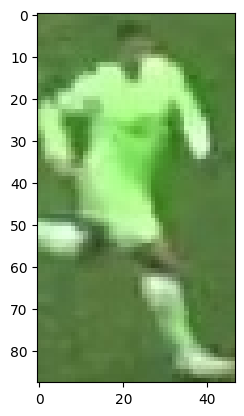

In [7]:
plt.imshow(image)
plt.show()

# take the top half of the image only

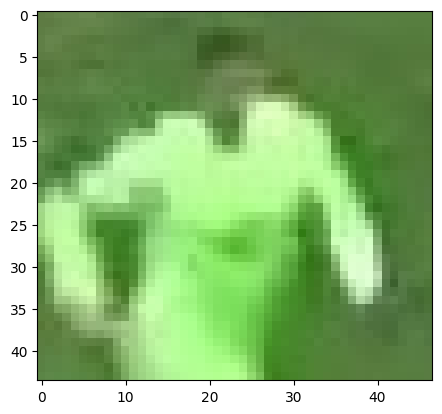

In [9]:
top_half_image=image[0: int(image.shape[0]/2),:]
plt.imshow(top_half_image)
plt.show()

# cluster the img into two clusters

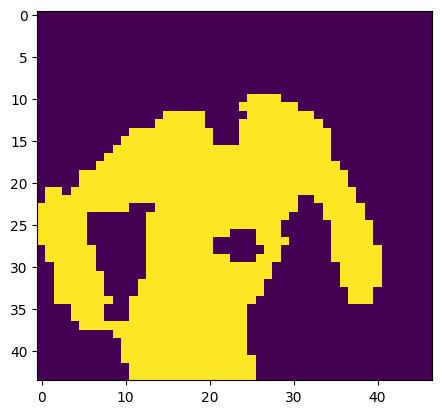

In [17]:
from sklearn import cluster
from types import new_class
#reshape the img into a 2d array
image_2d=top_half_image.reshape(-1,3)
#perform k_means clustering with 2 clusters : one for background color the other tshirt color
kmeans=KMeans(n_clusters=2,random_state=0)
kmeans.fit(image_2d)
#get the cluster labels
labels=kmeans.labels_
#reshape the labels into the original image shape
clustered_image=labels.reshape(top_half_image.shape[0],top_half_image.shape[1])
#displayu the clustered image
plt.imshow(clustered_image)
plt.show()

In [18]:
corner_clusters=[clustered_image[0,0],clustered_image[0,-1],clustered_image[-1,0],clustered_image[-1,-1]]
non_player_cluster=max(set(corner_clusters),key=corner_clusters.count)
print(non_player_cluster)
# to know what did kmeans assign to palyer and background cluster we look for most present cluster in the corners

0


In [19]:
player_cluster=1-non_player_cluster
print(player_cluster)
#this is always correct as it may change for new run ...


1


In [20]:
kmeans.cluster_centers_[player_cluster]
# returns the average BGR color of all pixels in the player cluster
# this is the dominant shirt color as [B, G, R] values

array([171.24470899, 235.64021164, 142.7962963 ])